ANÁLISE DE DESEMPENHO DE OPERADORES CALLMEMAYBE

A empresa CallMeMaybe que trabalha com serviço de telefonia busca um método de identificar dentre seus operadores quais são os menos rentáveis e eficientes.

Indicadores de um operador ineficiente:

- Possui muitas chamadas recebidas perdidas (internas ou externas);
- Apresenta tempo de espera prolongado nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza poucas chamadas ativas.

Importação de Bibliotecas

In [143]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats as st

Atribuição de Dataframe

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)

In [144]:
df_data = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

Leitura dos DataFrames

In [145]:
display(df_data.sample(30))

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
32060,167445,2019-11-25 00:00:00+03:00,out,False,920728.0,True,2,0,20
22020,167052,2019-11-07 00:00:00+03:00,out,False,904038.0,True,2,0,68
44456,168047,2019-11-19 00:00:00+03:00,out,False,937604.0,True,6,0,195
24506,167110,2019-10-16 00:00:00+03:00,in,False,NaN,True,1,0,1
28579,167185,2019-09-18 00:00:00+03:00,in,False,NaN,True,9,0,0
44495,168054,2019-11-27 00:00:00+03:00,in,False,NaN,True,24,0,586
22776,167071,2019-10-18 00:00:00+03:00,out,False,913938.0,True,1,0,21
11554,166692,2019-10-04 00:00:00+03:00,out,False,898892.0,True,1,0,35
39849,167756,2019-11-13 00:00:00+03:00,in,False,938896.0,False,24,1373,1526
36457,167626,2019-09-27 00:00:00+03:00,out,False,919162.0,True,87,0,2613


LIMPEZA E PROCESSAMENTO

In [146]:
# Converter operator_id de float para string e date para datetime

df_data['date'] = pd.to_datetime(df_data['date'], utc=True).dt.tz_localize(None)
df_data['operator_id'] = df_data['operator_id'].astype('Int64').astype(str).replace('<NA>', pd.NA)

# Criar coluna wait_time = total_call_duration − call_duration
df_data['wait_time'] = df_data['total_call_duration'] - df_data['call_duration']

# Verificar e remover duplicatas
df_data = df_data.drop_duplicates()

# Remover NaN em internal
df_data = df_data.dropna(subset=['internal'])

print(df_data.shape)
print(df_data.dtypes)

(48892, 10)
user_id                         int64
date                   datetime64[ns]
direction                      object
internal                       object
operator_id                    object
is_missed_call                   bool
calls_count                     int64
call_duration                   int64
total_call_duration             int64
wait_time                       int64
dtype: object


O Dataframe apresenta um alto número de NaNs para a coluna operator_id, por se tratar de uma grande quantidade de dados eu os manterei no DataFrame no momento e quando for preciso trabalhar com operator_id eu farei os calculos desconsiderando os NaNs

AGRUPAMENTO DE OPERADORES

In [147]:
df_operators = df_data.dropna(subset=['operator_id'])

df_grouped = df_operators.groupby('operator_id').agg(
    total_calls    = ('calls_count', 'sum'),
    missed_calls   = ('is_missed_call', 'sum'),
    avg_wait_time  = ('wait_time', 'mean'),
    outbound_calls = ('calls_count', lambda x: x[df_operators.loc[x.index, 'direction'] == 'out'].sum()),
).reset_index()

Calculando taxa de chamadas perdidas

In [148]:
df_grouped['missed_rate'] = df_grouped['missed_calls'] / df_grouped['total_calls']

print(df_grouped.shape)
display(df_grouped.head(20))

(1092, 6)


,operator_id,total_calls,missed_calls,avg_wait_time,outbound_calls,missed_rate
0,879896,930,47,104.914530,872,0.050538
1,879898,7312,89,459.690265,7209,0.012172
2,880020,45,6,14.000000,38,0.133333
3,880022,197,29,53.971429,189,0.147208
4,880026,2232,87,121.978022,2208,0.038978
5,880028,2560,82,210.178218,2497,0.032031
6,880240,47,7,47.333333,47,0.148936
7,881278,20,7,9.750000,20,0.350000
8,882476,3,0,31.666667,0,0.000000
9,882478,4,1,27.666667,1,0.250000


Percebe-se que há alguns operadores com poucas chamadas totais, vou criar um gráfico de dispersão para entender melhor aonde definir um limiar de corte

count     1092.000000
mean       642.934982
std       2889.647014
min          1.000000
25%         10.000000
50%         72.000000
75%        493.750000
max      60221.000000
Name: total_calls, dtype: float64


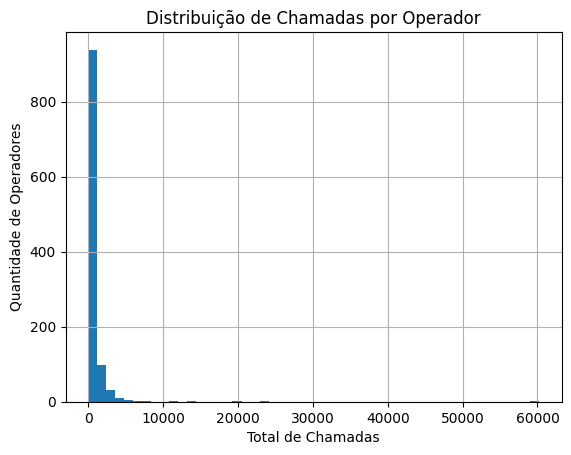

In [149]:
print(df_grouped['total_calls'].describe())
df_grouped['total_calls'].hist(bins=50)
plt.xlabel('Total de Chamadas')
plt.ylabel('Quantidade de Operadores')
plt.title('Distribuição de Chamadas por Operador')
plt.show()

De acordo com o gráfico o desvio padrão está em 2889 (muito alto) e com a mediana em 72, isso demonstra uma distribuição muito assimétrica, para isso vou cortar do cálculo operadores com total de chamadas menor que 50

In [150]:
df_grouped = df_grouped[df_grouped['total_calls'] >= 50]
print(df_grouped.shape)
display(df_grouped.head(20))

(587, 6)


,operator_id,total_calls,missed_calls,avg_wait_time,outbound_calls,missed_rate
0,879896,930,47,104.914530,872,0.050538
1,879898,7312,89,459.690265,7209,0.012172
3,880022,197,29,53.971429,189,0.147208
4,880026,2232,87,121.978022,2208,0.038978
5,880028,2560,82,210.178218,2497,0.032031
10,882680,99,3,37.000000,0,0.030303
11,882684,1274,54,128.480519,661,0.042386
12,882686,3650,83,288.763393,2884,0.022740
13,882688,58,3,157.111111,43,0.051724
14,882690,1588,23,581.761905,1417,0.014484


count      587.000000
mean      1184.512777
std       3861.407792
min         50.000000
25%        160.500000
50%        409.000000
75%       1272.500000
max      60221.000000
Name: total_calls, dtype: float64


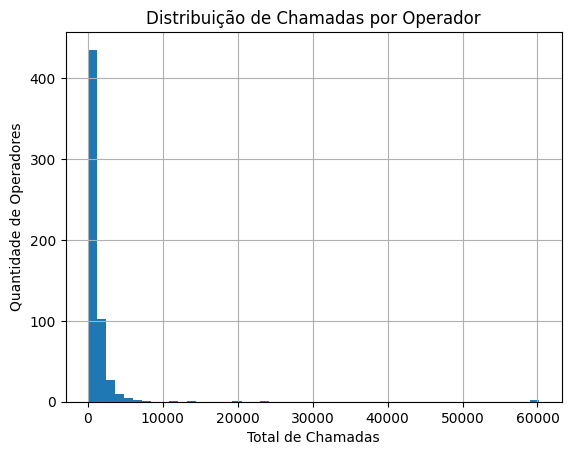

In [151]:
print(df_grouped['total_calls'].describe())
df_grouped['total_calls'].hist(bins=50)
plt.xlabel('Total de Chamadas')
plt.ylabel('Quantidade de Operadores')
plt.title('Distribuição de Chamadas por Operador')
plt.show()

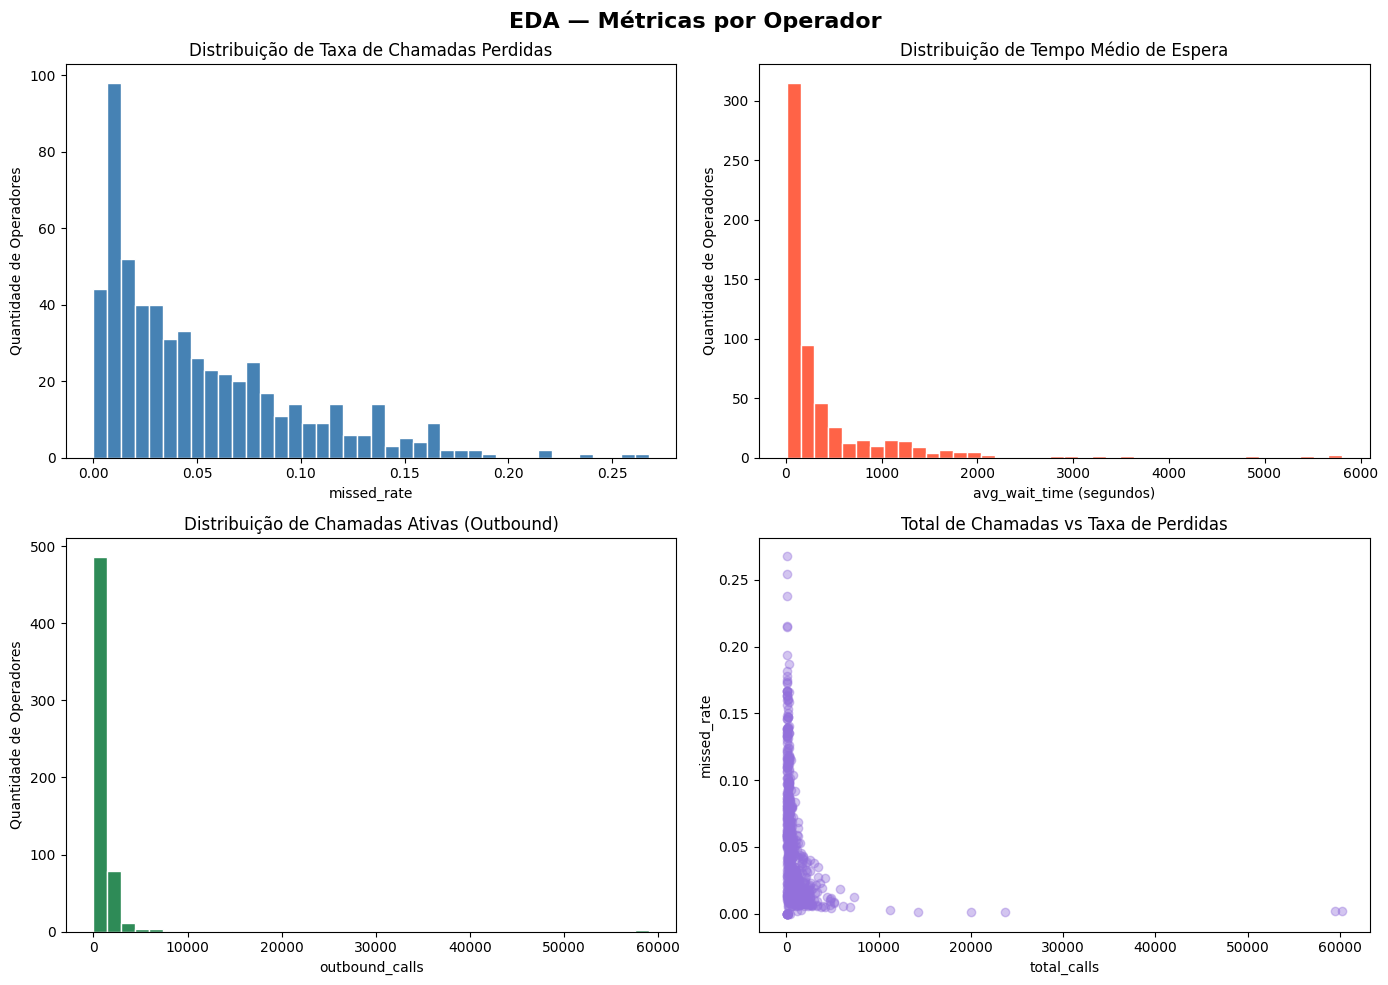

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Métricas por Operador', fontsize=16, fontweight='bold')

# 1. Distribuição de missed_rate
axes[0, 0].hist(df_grouped['missed_rate'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribuição de Taxa de Chamadas Perdidas')
axes[0, 0].set_xlabel('missed_rate')
axes[0, 0].set_ylabel('Quantidade de Operadores')

# 2. Distribuição de avg_wait_time
axes[0, 1].hist(df_grouped['avg_wait_time'], bins=40, color='tomato', edgecolor='white')
axes[0, 1].set_title('Distribuição de Tempo Médio de Espera')
axes[0, 1].set_xlabel('avg_wait_time (segundos)')
axes[0, 1].set_ylabel('Quantidade de Operadores')

# 3. Distribuição de outbound_calls
axes[1, 0].hist(df_grouped['outbound_calls'], bins=40, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Distribuição de Chamadas Ativas (Outbound)')
axes[1, 0].set_xlabel('outbound_calls')
axes[1, 0].set_ylabel('Quantidade de Operadores')

# 4. Relação entre total_calls e missed_rate
axes[1, 1].scatter(df_grouped['total_calls'], df_grouped['missed_rate'], alpha=0.4, color='mediumpurple')
axes[1, 1].set_title('Total de Chamadas vs Taxa de Perdidas')
axes[1, 1].set_xlabel('total_calls')
axes[1, 1].set_ylabel('missed_rate')

plt.tight_layout()
plt.show()

Taxa de Chamadas Perdidas (missed_rate)
A maioria dos operadores fica entre 0 e 5% de taxa de perdidas. Mas tem uma cauda longa chegando em 27% — esses são os candidatos a ineficientes. A distribuição é assimétrica à direita.

Tempo Médio de Espera (avg_wait_time)
A grande maioria fica abaixo de 500 segundos, mas existem alguns operadores com valores absurdos chegando em quase 6000 segundos (~1h40). Esses são claramente outliers e provavelmente os mesmos dois que identificamos antes (885876 e 885890).

Chamadas Ativas Outbound
Quase todos os operadores fazem menos de 5000 chamadas ativas. Os dois outliers com 58k+ chamadas distorcem o gráfico inteiro — são os mesmos do wait_time provavelmente.

Total de Chamadas vs Taxa de Perdidas
Padrão claro: operadores com poucos total_calls tendem a ter missed_rate mais alta e mais variável. Operadores com alto volume têm missed_rate consistentemente baixa. Isso reforça que o corte de 50 chamadas mínimas foi uma boa decisão.

In [153]:
# Separando operadores inbound e outbound
df_inbound  = df_grouped[df_grouped['outbound_calls'] == 0].copy()
df_outbound = df_grouped[df_grouped['outbound_calls'] >  0].copy()

# Ranking inbound — só missed_rate e avg_wait_time
df_inbound['rank_missed'] = df_inbound['missed_rate'].rank(ascending=False)
df_inbound['rank_wait']   = df_inbound['avg_wait_time'].rank(ascending=False)
df_inbound['inefficiency_score'] = df_inbound['rank_missed'] + df_inbound['rank_wait']

# Ranking outbound — os 3 critérios
df_outbound['rank_missed']   = df_outbound['missed_rate'].rank(ascending=False)
df_outbound['rank_wait']     = df_outbound['avg_wait_time'].rank(ascending=False)
df_outbound['rank_outbound'] = df_outbound['outbound_calls'].rank(ascending=True)
df_outbound['inefficiency_score'] = df_outbound['rank_missed'] + df_outbound['rank_wait'] + df_outbound['rank_outbound']

# Rankings finais
df_ranking_inbound  = df_inbound.sort_values('inefficiency_score', ascending=False).reset_index(drop=True)
df_ranking_outbound = df_outbound.sort_values('inefficiency_score', ascending=False).reset_index(drop=True)

print('Operadores Inbound:', len(df_ranking_inbound))
print('Operadores Outbound:', len(df_ranking_outbound))

print('\nTop 10 Ineficientes — Inbound')
display(df_ranking_inbound[['operator_id', 'missed_rate', 'avg_wait_time', 'inefficiency_score']].head(10))

print('\nTop 10 Ineficientes — Outbound')
display(df_ranking_outbound[['operator_id', 'missed_rate', 'avg_wait_time', 'outbound_calls', 'inefficiency_score']].head(10))

Operadores Inbound: 29
Operadores Outbound: 558

Top 10 Ineficientes — Inbound


,operator_id,missed_rate,avg_wait_time,inefficiency_score
0,944808,0.000000,17.500000,52.5
1,895578,0.000000,22.810811,51.5
2,952734,0.000000,23.789474,49.5
3,936984,0.000000,30.250000,47.5
4,896012,0.004098,23.725806,44.0
5,920982,0.000000,48.222222,41.5
6,961770,0.000000,54.125000,38.5
7,910018,0.000000,59.020408,34.5
8,895574,0.010417,30.978723,34.0
9,936110,0.000000,60.850000,33.5



Top 10 Ineficientes — Outbound


,operator_id,missed_rate,avg_wait_time,outbound_calls,inefficiency_score
0,929424,0.008034,505.547619,3963,1168.0
1,891414,0.037654,92.000000,2498,1163.0
2,894656,0.021650,204.078431,3167,1141.0
3,893804,0.018816,263.480969,3413,1140.0
4,891410,0.035031,128.655172,2737,1135.0
5,879898,0.012172,459.690265,7209,1126.0
6,901880,0.026523,167.890000,2362,1119.0
7,929428,0.001347,5478.123077,23754,1116.0
8,908640,0.001475,3537.860465,14239,1115.0
9,952948,0.009750,227.031579,1178,1114.5


In [154]:
# Definindo limiar de ineficiência pelo percentil 75
p75_inbound  = df_ranking_inbound['inefficiency_score'].quantile(0.75)
p75_outbound = df_ranking_outbound['inefficiency_score'].quantile(0.75)

# Classificando operadores
df_ranking_inbound['inefficient']  = df_ranking_inbound['inefficiency_score']  >= p75_inbound
df_ranking_outbound['inefficient'] = df_ranking_outbound['inefficiency_score'] >= p75_outbound

print(f'Limiar Inbound:  {p75_inbound:.1f}')
print(f'Limiar Outbound: {p75_outbound:.1f}')
print()
print(f'Operadores ineficientes Inbound:  {df_ranking_inbound["inefficient"].sum()} de {len(df_ranking_inbound)}')
print(f'Operadores ineficientes Outbound: {df_ranking_outbound["inefficient"].sum()} de {len(df_ranking_outbound)}')

Limiar Inbound:  34.5
Limiar Outbound: 973.4

Operadores ineficientes Inbound:  8 de 29
Operadores ineficientes Outbound: 140 de 558


In [155]:
# Separando grupos para H1
eficientes_missed   = df_ranking_outbound[df_ranking_outbound['inefficient'] == False]['missed_rate']
ineficientes_missed = df_ranking_outbound[df_ranking_outbound['inefficient'] == True]['missed_rate']

# Teste de normalidade
stat, p_eficientes   = st.shapiro(eficientes_missed)
stat, p_ineficientes = st.shapiro(ineficientes_missed)

print(f'Shapiro eficientes:   p = {p_eficientes:.4f}')
print(f'Shapiro ineficientes: p = {p_ineficientes:.4f}')

# Mann-Whitney U
stat, p_value = st.mannwhitneyu(ineficientes_missed, eficientes_missed, alternative='less')

print(f'p-value: {p_value:.50f}')
if p_value < 0.05:
    print('Resultado: Rejeitamos H0 — operadores ineficientes têm taxa de chamadas perdidas significativamente maior')
else:
    print('Resultado: Não rejeitamos H0 — não há diferença significativa na taxa de chamadas perdidas')

Shapiro eficientes:   p = 0.0000
Shapiro ineficientes: p = 0.0000
p-value: 0.00000000000000000000000000000000000000000032403841
Resultado: Rejeitamos H0 — operadores ineficientes têm taxa de chamadas perdidas significativamente maior


In [156]:
# Separando grupos para H2
eficientes_wait   = df_ranking_outbound[df_ranking_outbound['inefficient'] == False]['avg_wait_time']
ineficientes_wait = df_ranking_outbound[df_ranking_outbound['inefficient'] == True]['avg_wait_time']

# Teste de normalidade
stat, p_eficientes   = st.shapiro(eficientes_wait)
stat, p_ineficientes = st.shapiro(ineficientes_wait)

print(f'Shapiro eficientes:   p = {p_eficientes:.40f}')
print(f'Shapiro ineficientes: p = {p_ineficientes:.40f}')

# Mann-Whitney U
stat, p_value = st.mannwhitneyu(ineficientes_wait, eficientes_wait, alternative='greater')

print(f'\nMann-Whitney U — H2 (avg_wait_time)')
print(f'p-value: {p_value:.40f}')
print()
if p_value < 0.05:
    print('Resultado: Rejeitamos H0 — operadores ineficientes têm tempo de espera significativamente maior')
else:
    print('Resultado: Não rejeitamos H0 — não há diferença significativa no tempo de espera')

Shapiro eficientes:   p = 0.0000000000000000000000000000366016570070
Shapiro ineficientes: p = 0.0000000000000115817795776459028842230939

Mann-Whitney U — H2 (avg_wait_time)
p-value: 0.0000000000000000000000000000000000003537

Resultado: Rejeitamos H0 — operadores ineficientes têm tempo de espera significativamente maior


In [159]:
# Separando grupos para H3
eficientes_out   = df_ranking_outbound[df_ranking_outbound['inefficient'] == False]['outbound_calls']
ineficientes_out = df_ranking_outbound[df_ranking_outbound['inefficient'] == True]['outbound_calls']

# Teste de normalidade
stat, p_eficientes   = st.shapiro(eficientes_out)
stat, p_ineficientes = st.shapiro(ineficientes_out)

print(f'Shapiro eficientes:   p = {p_eficientes:.40f}')
print(f'Shapiro ineficientes: p = {p_ineficientes:.40f}')

# Mann-Whitney U — ineficientes fazem MENOS chamadas ativas
stat, p_value = st.mannwhitneyu(ineficientes_out, eficientes_out, alternative='greater')

print(f'p-value: {p_value:.70f}')
if p_value < 0.05:
    print('Resultado: Rejeitamos H0 — operadores ineficientes realizam menos chamadas ativas')
else:
    print('Resultado: Não rejeitamos H0 — não há diferença significativa no volume de chamadas ativas')

Shapiro eficientes:   p = 0.0000000000000000000075538756051712912769
Shapiro ineficientes: p = 0.0000000000000000000000223665760604352704
p-value: 0.0000000000000000000000000000000000000000000000000000000000000242952432
Resultado: Rejeitamos H0 — operadores ineficientes realizam menos chamadas ativas
